#Задача регрессии

Вы будете анализировать один из известных в области анализа данных датасетов, описывающих качество белого и красного вина с помощью их физико-химических свойств. Выберите один из 2 датасетов (репозиторий UCI) https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/. Ознакомьтесь с их описанием https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality.names, осуществите при необходимости перевод на русский язык.


Импорт необходимых модулей

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.linear_model import LinearRegression as lm

#Разведочный анализ датасета и визуализация данных

Считывание данных в датафрейм, информация о нем и просмотр его верхней части

In [2]:
#  Ваш код здесь
df=pd.read_csv('winequality-red.csv',sep=';')
df=df.rename(columns={"fixed acidity":"фиксированая кислотность","volatile acidity":"летучая кислотность","citric acid":"лимонная кислота",
                       "residual sugar":"остаточный сахар","chlorides":"хлориды","free sulfur dioxide":"свободный диоксид серы",
                      "total sulfur dioxide":"общий диоксид серы","density":"плотность","sulphates":"сульфаты",
                      "alcohol":"алкоголь","quality":"качество"})
df.info()
print("Набор уникальных значений для качества",df['качество'].unique())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   фиксированая кислотность  1599 non-null   float64
 1   летучая кислотность       1599 non-null   float64
 2   лимонная кислота          1599 non-null   float64
 3   остаточный сахар          1599 non-null   float64
 4   хлориды                   1599 non-null   float64
 5   свободный диоксид серы    1599 non-null   float64
 6   общий диоксид серы        1599 non-null   float64
 7   плотность                 1599 non-null   float64
 8   pH                        1599 non-null   float64
 9   сульфаты                  1599 non-null   float64
 10  алкоголь                  1599 non-null   float64
 11  качество                  1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
Набор уникальных значений для качества [5 6 7 4 8 3]


,фиксированая кислотность,летучая кислотность,лимонная кислота,остаточный сахар,хлориды,свободный диоксид серы,общий диоксид серы,плотность,pH,сульфаты,алкоголь,качество
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Вывод описательной статистики по датасету. Какие заключения можно сделать о данных по полученным результатам?

In [3]:
df.describe()
#В целом, значения параметров лежат довольно близко (средние значения лежат в небольшом диапозоне)
#Имеется несколько параметров с относительно большими и малыми значениями. Возможно потребуется нормировка.

,фиксированая кислотность,летучая кислотность,лимонная кислота,остаточный сахар,хлориды,свободный диоксид серы,общий диоксид серы,плотность,pH,сульфаты,алкоголь,качество
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Парные диаграммы. Постройте диаграммы рассеяния. Можно ли заметить какие-то тенденции из анализа парных диаграмм?

<Figure size 1350x1350 with 0 Axes>

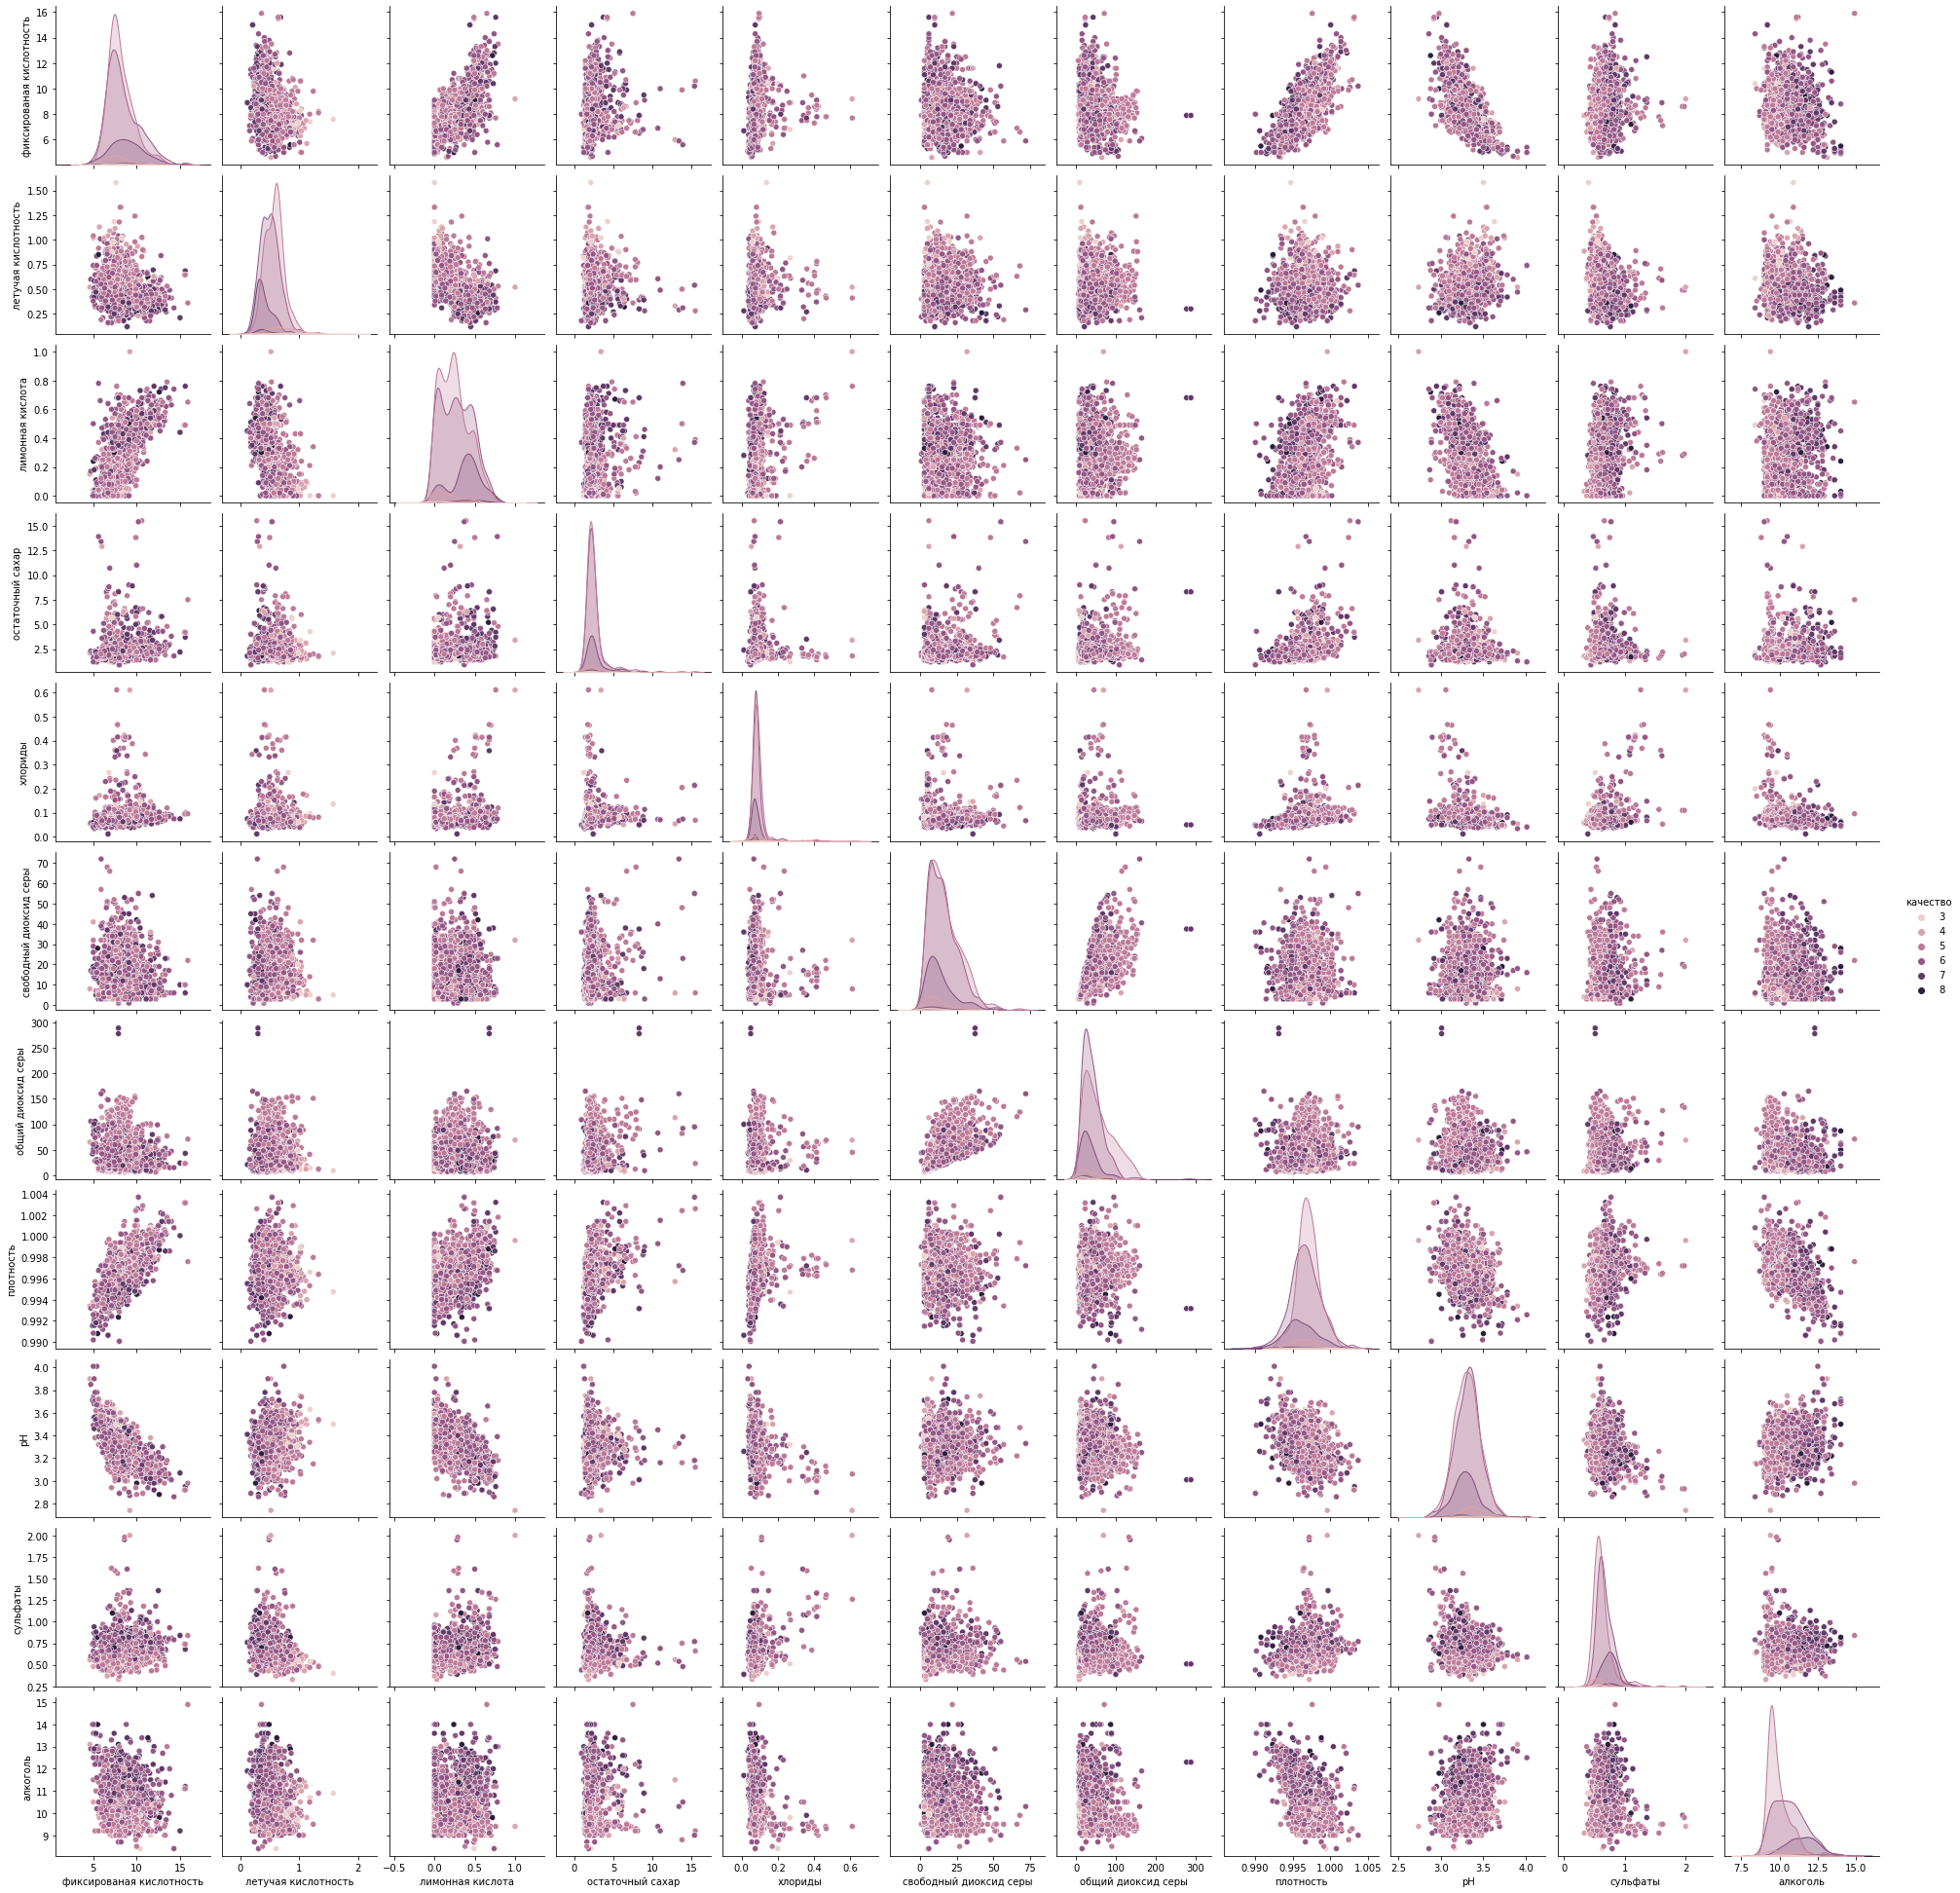

In [4]:
#  Ваш код здесь
plt.figure(figsize=(15,15), dpi=90)
sns.pairplot(data=df, kind="scatter",hue="качество")

Корреляционная матрица. Постройте корреляционную матрицу и диаграмму корреляции. Для каких переменных можно заподозрить существование взаимосвязи?

In [5]:
#  Ваш код здесь
df.corr(method='pearson')
#Существует связь между фиксированной кислотностью и летучей кислотоностью (0,67)
#Существует связь между фиксированной кислотностью и плотностью (0,668)
#Существует обратная связь между фиксированной кислотностью и pH (-0,682)
#и т.д.

,фиксированая кислотность,летучая кислотность,лимонная кислота,остаточный сахар,хлориды,свободный диоксид серы,общий диоксид серы,плотность,pH,сульфаты,алкоголь,качество
фиксированая кислотность,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
летучая кислотность,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
лимонная кислота,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
остаточный сахар,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
хлориды,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
свободный диоксид серы,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
общий диоксид серы,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
плотность,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
сульфаты,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


Диаграмма корреляции

<AxesSubplot:>

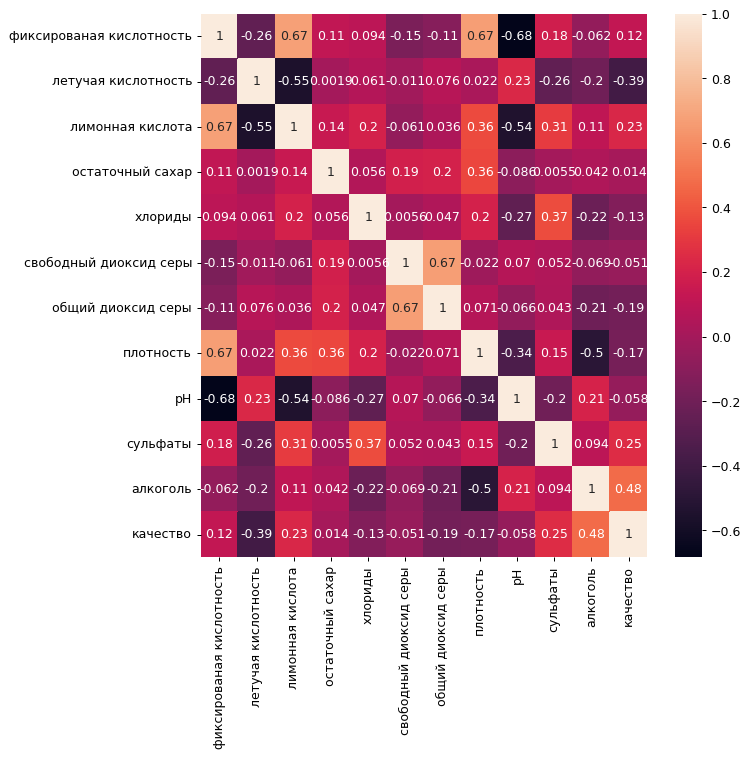

In [6]:
#  Ваш код здесь
plt.figure(figsize=(8,8), dpi=90)
sns.heatmap(df.corr(), xticklabels=df.corr().columns, yticklabels=df.corr().columns, annot=True)

Отдельно постройте диаграмму рассеяния для переменных с высокими значениями модуля коэффициента корреляции. Что, по-Вашему, означает такое число и такая диаграмма?

Text(0, 0.5, 'лимонная кислота')

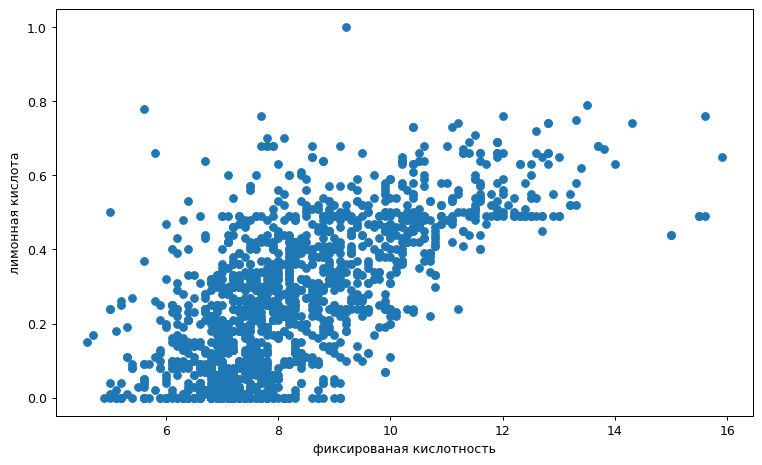

In [7]:
#  Ваш код здесь
plt.figure(figsize=(10,6), dpi=90)
plt.scatter(df['фиксированая кислотность'], df['лимонная кислота'])
plt.xlabel('фиксированая кислотность')
plt.ylabel('лимонная кислота')
#коеффициент корреляции показывает насколько один параметр связан с другим. По графику можно увидеть некоторую закономерность распределения точек на плоскости. Значения (по модулю) выше 0.5,вероятно, имеют среднюю связь.

Text(0, 0.5, 'плотность')

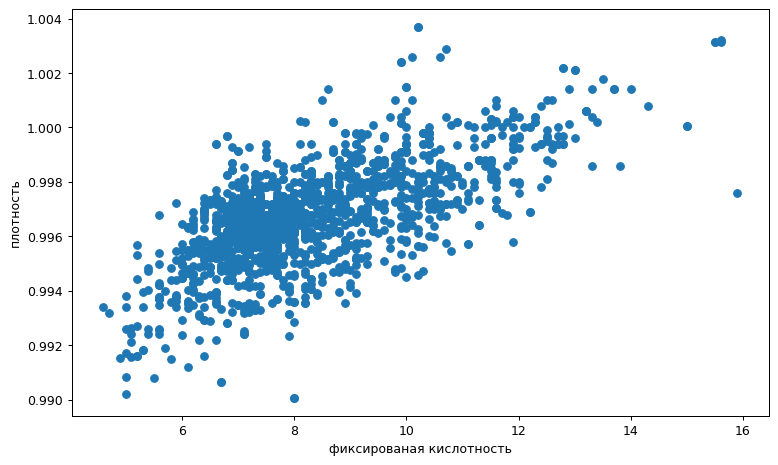

In [8]:
plt.figure(figsize=(10,6), dpi=90)
plt.scatter(df['фиксированая кислотность'], df['плотность'])
plt.xlabel('фиксированая кислотность')
plt.ylabel('плотность')

Text(0, 0.5, 'pH')

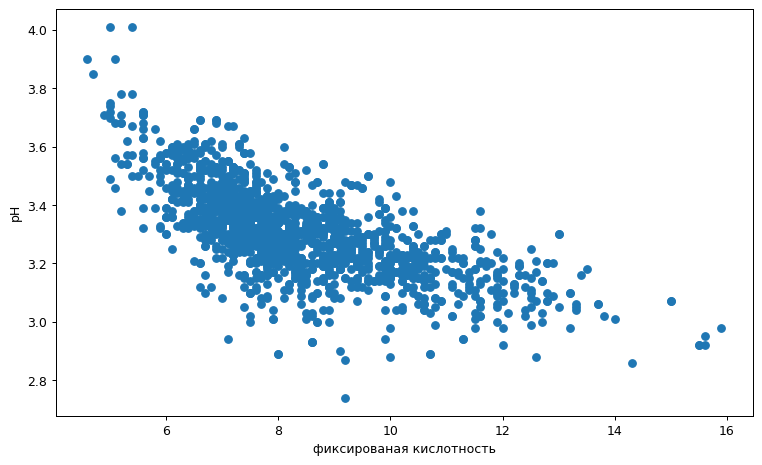

In [9]:
plt.figure(figsize=(10,6), dpi=90)
plt.scatter(df['фиксированая кислотность'], df['pH'])
plt.xlabel('фиксированая кислотность')
plt.ylabel('pH')

Text(0, 0.5, 'лимонная кислота')

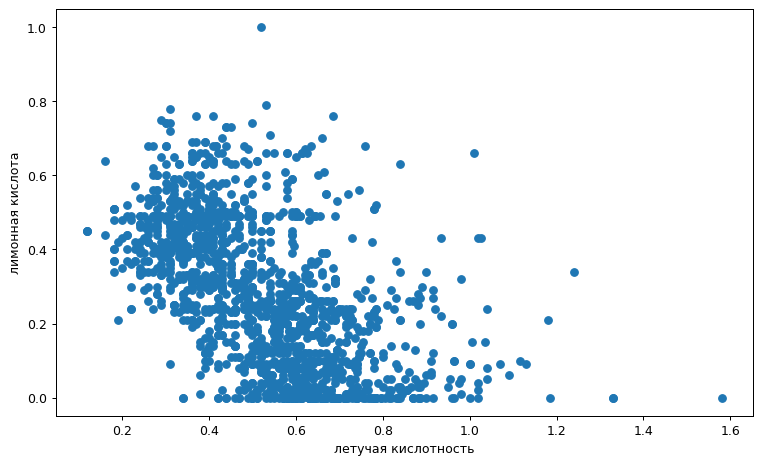

In [10]:
plt.figure(figsize=(10,6), dpi=90)
plt.scatter(df['летучая кислотность'], df['лимонная кислота'])
plt.xlabel('летучая кислотность')
plt.ylabel('лимонная кислота')

Text(0, 0.5, 'лимонная кислота')

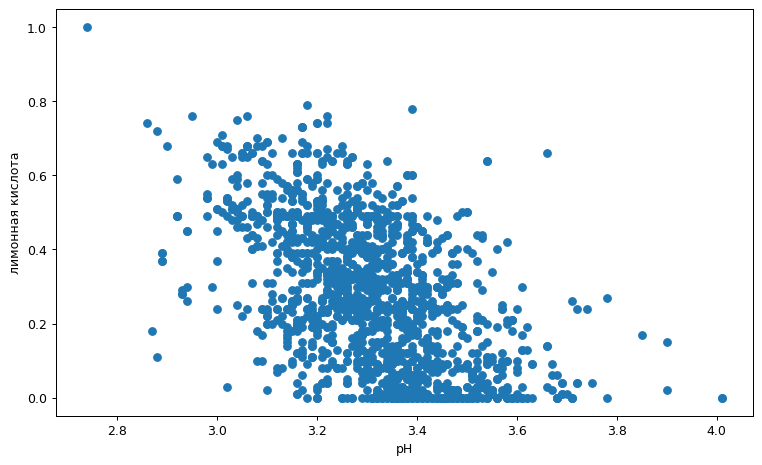

In [11]:
plt.figure(figsize=(10,6), dpi=90)
plt.scatter(df['pH'], df['лимонная кислота'])
plt.xlabel('pH')
plt.ylabel('лимонная кислота')

Text(0, 0.5, 'алкоголь')

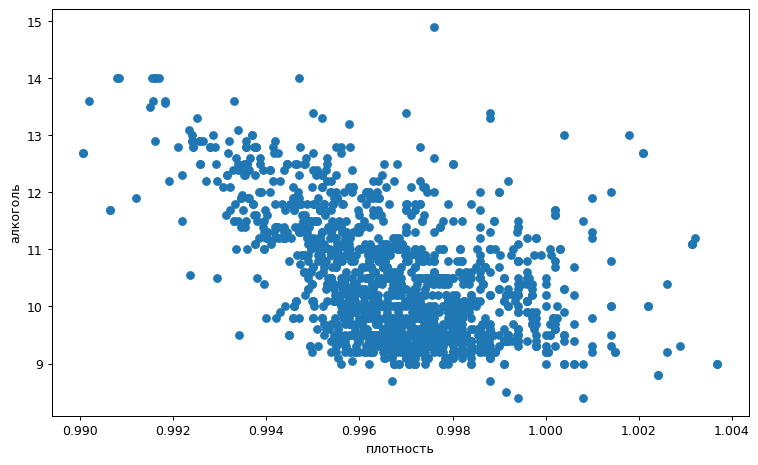

In [12]:
plt.figure(figsize=(10,6), dpi=90)
plt.scatter(df['плотность'], df['алкоголь'])
plt.xlabel('плотность')
plt.ylabel('алкоголь')

Text(0, 0.5, 'алкоголь')

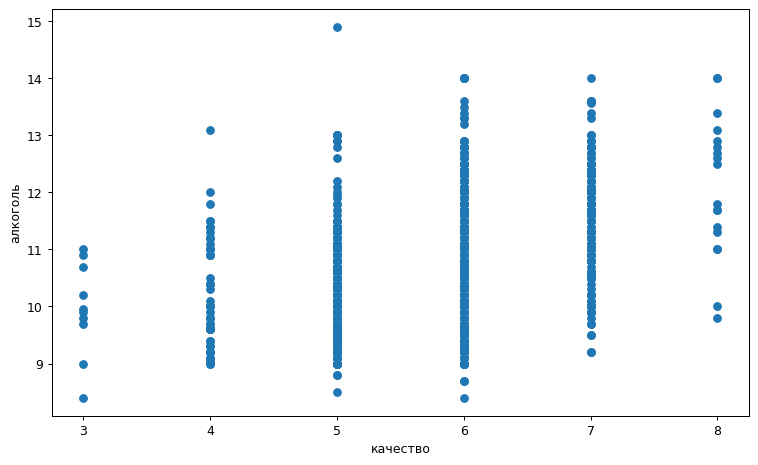

In [13]:
plt.figure(figsize=(10,6), dpi=90)
plt.scatter(df['качество'], df['алкоголь'])
plt.xlabel('качество')
plt.ylabel('алкоголь')

#Построение модели линейной регрессии

$y = a_0 + a_1x$ - уравнение прямой

Выделение зависимой (целевой) переменной y

In [26]:
#  Ваш код здесь
y=df['качество'].values
print(y)


[5 5 5 ... 6 5 6]


Выделение независимой переменной-предиктора X

In [27]:
#  Ваш код здесь
X = pd.DataFrame(df['алкоголь'])

Разбейте датасет на обучающую и тестовую выборки. Какую пропорцию разбиения разумней использовать? Почему?

In [28]:
#  Ваш код здесь
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
#В качестве учебной была выбрана выборка из 80%, чтобы было достаточное кол-во объектов для обучения

Постройте регрессионную (линейную) модель по обучающей выборке и выведите коэффициенты уравнения регрессии:

In [29]:
#  Ваш код здесь
model = lm()
model.fit(X_train, y_train)
#a0
a0=model.intercept_
print(model.intercept_)
#a1
a1=model.coef_
print(model.coef_)

1.846049105828241
[0.36494637]


Постройте диаграмму рассеяния данных обучающей выборки и проведите через корреляционное облако прямую с использованием найденных коэффициентов уравнения линейной регрессии

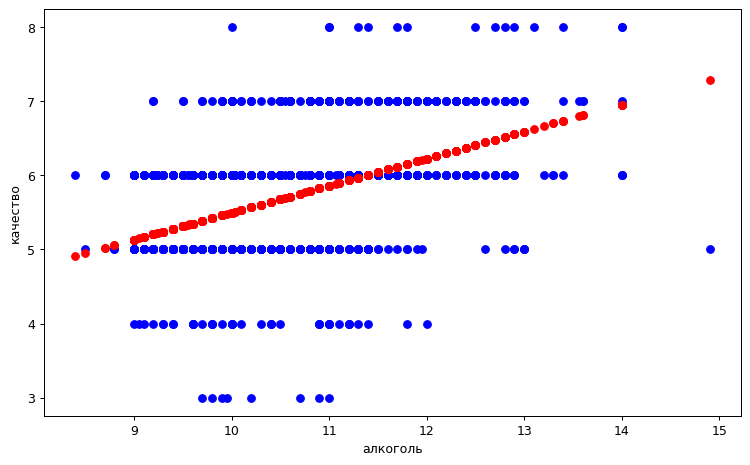

In [31]:
#  Ваш код здесь
plt.figure(figsize=(10,6), dpi=90)
plt.plot(X_train, y_train, 'ob')
y_train_lm=a0+X_train*a1
plt.plot(X_train, y_train_lm, 'or')
plt.xlabel('алкоголь')
plt.ylabel('качество')
plt.show()

Выполните на тестовой выборке прогнозирование с использованием построенной модели и сравните результаты работы модели с реальными данными

In [32]:
#  Ваш код здесь
y_test_pred=model.predict(X_test)
sse=sst=0
mean=y_test.mean()
sum=0
for i in range(y_test.shape[0]):
    sse+=math.pow(y_test[i]-y_test_pred[i],2)
    sst+=(y_test[i]-mean)*(y_test[i]-mean)
    sum+=math.fabs((y_test[i]-y_test_pred[i])/y_test[i])
print('Среднее относительное отклонение: {:.2f}%'.format(sum/y_test.shape[0]*100))
print('R2(test): '+str(1-sse/sst))
print('R2(train): '+str(model.score(X_train,y_train)))
print('R2(model): '+str(model.score(X,y)))
#Результаты для всех случаев показывают, что выбранная переменная X слабо объясняет
#изменение переменной y. На тестовой выборке показатель незначительно лучше.

Среднее относительное отклонение: 9.69%
R2(test): 0.23757247151260164
R2(train): 0.22338365027505935
R2(model): 0.22641044144082567


Оцените качество предсказания с использованием метрики RMSE и диаграммы остатков

RMSE_test = 0.661


Text(0, 0.5, 'Остатки')

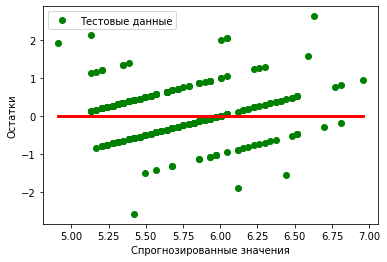

In [33]:
#  Ваш код здесь
from sklearn.metrics import mean_squared_error

print('RMSE_test = {:.3f}'.format(
        np.sqrt(mean_squared_error(y_test, y_test_pred))))


plt.plot(y_test_pred, y_test_pred-y_test,
            'og', label='Тестовые данные')
plt.plot(y_test_pred,np.zeros((X_test.shape[0])), '-r', lw=3)
plt.legend(loc='upper left')
plt.xlabel('Спрогнозированные значения')
plt.ylabel('Остатки')

#Модель линейной регрессии с несколькими предикторами

Постройте регрессионную модель с несколькими предикторами $y = a_0 + a_1x_1 + a_2x_2 + a_3x_3 + a_4x_4 + ...$ - уравнение прямой в многомерном пространстве.

Выделение зависимой (целевой) переменной y



In [22]:
#  Ваш код здесь
y=df["качество"].values

Выделение независимых переменных-предикторов X

In [34]:
#  Ваш код здесь
X=df.iloc[:,:-1]
X

,фиксированая кислотность,летучая кислотность,лимонная кислота,остаточный сахар,хлориды,свободный диоксид серы,общий диоксид серы,плотность,pH,сульфаты,алкоголь
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


Разбейте датасет на обучающую и тестовую выборки. Какую пропорцию разбиения разумней использовать? Почему?



In [35]:
#  Ваш код здесь
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
#В качестве учебной была выбрана выборка из 80%, чтобы было достаточное кол-во объектов для обучения

Постройте регрессионную (линейную) модель по обучающей выборке и выведите коэффициенты уравнения регрессии. Попробуйте интерпретировать значения полученных коэффициентов

In [36]:
#  Ваш код здесь
model = lm().fit(X_train, y_train)

print('a0: {:.2f}'.format(model.intercept_))
print('a: ', model.coef_)
#Переменные, коэффициенты которых с отрицательными степенями либо незначимы, либо "уравниваются"
#с переменными, имеющими меньшие значения. Знаки перед коэффициентами используются для лучшей
#подгонки модели к целевому значению.

a0: 35.00
a:  [ 4.12835075e-02 -1.14952802e+00 -1.77927063e-01  2.78700036e-02
 -1.87340739e+00  2.68362616e-03 -2.77748370e-03 -3.15166657e+01
 -2.54486051e-01  9.24040106e-01  2.67797417e-01]


Выполните на тестовой выборке прогнозирование с использованием построенной модели и сравните результаты работы модели с реальными данными

In [37]:
#  Ваш код здесь
y_test_pred=model.predict(X_test)
sse=sst=0
mean=y_test.mean()
sum=0
for i in range(y_test.shape[0]):
    sse+=math.pow(y_test[i]-y_test_pred[i],2)
    sst+=(y_test[i]-mean)*(y_test[i]-mean)
    sum+=math.fabs((y_test[i]-y_test_pred[i])/y_test[i])
print('Среднее относительное отклонение: {:.2f}%'.format(sum/y_test.shape[0]*100))
print('R2(test): '+str(1-sse/sst))
print('R2(train): '+str(model.score(X_train,y_train)))
print('R2(model): '+str(model.score(X,y)))
#Результаты для всех случаев показывают, что выбранная переменная X слабо объясняет
#изменение переменной y. На тестовой выборке показатель незначительно хуже. Но в целом
#модель со многими переменными объясняет y лучше, чем одна переменная.

Среднее относительное отклонение: 8.78%
R2(test): 0.3283887639580212
R2(train): 0.3654519616206868
R2(model): 0.3593724283394687


Оцените качество предсказания с использованием метрики RMSE

RMSE_test = 0.620


Text(0, 0.5, 'Остатки')

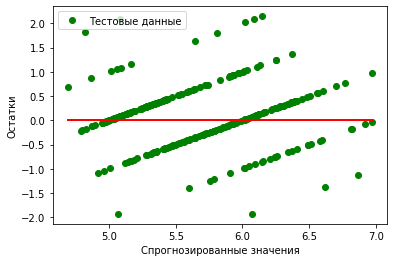

In [38]:
#  Ваш код здесь
from sklearn.metrics import mean_squared_error

print('RMSE_test = {:.3f}'.format(
        np.sqrt(mean_squared_error(y_test, y_test_pred))))
#print(np.sqrt(np.mean((y_test-y_test_pred)**2)))


plt.plot(y_test_pred, y_test_pred-y_test,
            'og', label='Тестовые данные')
plt.plot(y_test_pred, np.zeros((X_test.shape[0])), '-r', lw=2)
plt.legend(loc='upper left')
plt.xlabel('Спрогнозированные значения')
plt.ylabel('Остатки')

## <center> Регрессионные модели, основанные на деревьях решений

### 1. Модель деревьев решений

Постройте регрессионную модель деревьев решений (с использованием DecisionTreeRegressor из sklearn.tree) и выполните предсказание с ее помощью

In [39]:
#  Ваш код здесь
from sklearn.tree import DecisionTreeRegressor
y = df["качество"]
x = df.iloc[:,:-1]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

model = DecisionTreeRegressor()
model.fit(X_train,y_train)

DecisionTreeRegressor()

Выполните на тестовой выборке прогнозирование с использованием построенной модели и сравните результаты работы модели с реальными данными

In [40]:
#  Ваш код здесь
y_pred = model.predict(X_test)
df1 = pd.DataFrame({'Test': y_test, 'Predicted': y_pred,'Delta':y_pred-y_test})

print('R2(test): '+str(model.score(X_test,y_test)))
print('R2(train): '+str(model.score(X_train,y_train)))
print('R2(model): '+str(model.score(x,y)))
#модель идеально соответстует данным, на которых обучалась, но при этом показывает
#отвратительные результаты на тестовой выборке
print(df1)

R2(test): -0.2828386216308427
R2(train): 1.0
R2(model): 0.7745078977593911
      Test  Predicted  Delta
1109     6        5.0   -1.0
1032     5        5.0    0.0
1002     7        7.0    0.0
487      6        5.0   -1.0
979      5        5.0    0.0
...    ...        ...    ...
794      6        6.0    0.0
813      4        6.0    2.0
1322     5        6.0    1.0
704      4        5.0    1.0
1023     6        7.0    1.0

[320 rows x 3 columns]


Оцените качество предсказания с использованием метрики RMSE

RMSE_test = 0.857


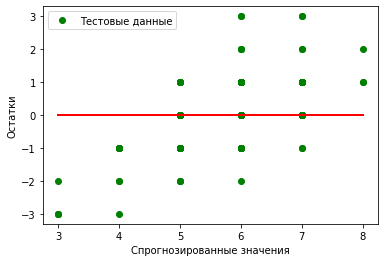

In [41]:
#  Ваш код здесь
print('RMSE_test = {:.3f}'.format(
        np.sqrt(mean_squared_error(y_test, y_pred))))

plt.plot(y_pred,  y_pred - y_test, 'og', label='Тестовые данные')
plt.xlabel('Спрогнозированные значения')
plt.ylabel('Остатки')
plt.legend(loc='upper left')
plt.plot(y_pred, np.zeros((y_pred.shape[0])), lw=2, color='red')

### 2. Модель RandomForest

Постройте регрессионную модель на основе RandomForest (с использованием sklearn.ensemble и RandomForestRegressor) и выполните предсказание с ее помощью

In [42]:
#  Ваш код здесь
from sklearn.ensemble import RandomForestRegressor
y = df["качество"]
x = df.iloc[:,:-1]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

model = RandomForestRegressor()
model.fit(X_train,y_train)

RandomForestRegressor()

Выполните на тестовой выборке прогнозирование с использованием построенной модели и сравните результаты работы модели с реальными данными

In [43]:
#  Ваш код здесь
y_pred = model.predict(X_test)
df1 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred,'Delta':y_pred-y_test})
print('R2(test): '+str(model.score(X_test,y_test)))
print('R2(train): '+str(model.score(X_train,y_train)))
print('R2(model): '+str(model.score(x,y)))
#Модель хорошо соответствует данным на которых обучалась, но имеет "средние"
#показатели на тестовой выборке.
print(df1)

R2(test): 0.4387493688161037
R2(train): 0.930800092282353
R2(model): 0.8443569070739585
      Actual  Predicted  Delta
1109       6       5.31  -0.69
1032       5       4.87  -0.13
1002       7       6.93  -0.07
487        6       5.04  -0.96
979        5       5.19   0.19
...      ...        ...    ...
794        6       6.42   0.42
813        4       5.87   1.87
1322       5       6.35   1.35
704        4       5.05   1.05
1023       6       6.48   0.48

[320 rows x 3 columns]


Оцените качество предсказания с использованием метрики RMSE

RMSE_test = 0.567


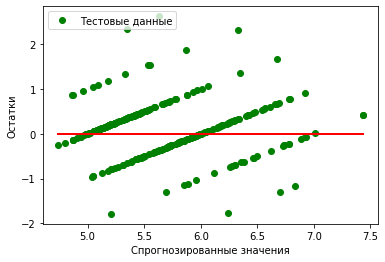

In [44]:
#  Ваш код здесь
print('RMSE_test = {:.3f}'.format(
        np.sqrt(mean_squared_error(y_test, y_pred))))

plt.plot(y_pred,  y_pred - y_test, 'og', label='Тестовые данные')
plt.xlabel('Спрогнозированные значения')
plt.ylabel('Остатки')
plt.legend(loc='upper left')
plt.plot(y_pred, np.zeros((y_pred.shape[0])), lw=2, color='red')

### 3. Модели на базе алгоритмов бустинга

Постройте регрессионные модели на основе XGBoost и CatBoost. Выполните предсказание с их помощью

In [45]:
#  Ваш код здесь
import xgboost as xgb
from catboost import Pool, CatBoostRegressor

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

model1 = xgb.XGBRegressor()
model1.fit(X_train,y_train)
model2 = CatBoostRegressor()
model2.fit(X_train,y_train)

Learning rate set to 0.042566
0:	learn: 0.8072847	total: 136ms	remaining: 2m 15s
1:	learn: 0.7965140	total: 138ms	remaining: 1m 8s
2:	learn: 0.7870735	total: 140ms	remaining: 46.5s
3:	learn: 0.7766546	total: 142ms	remaining: 35.3s
4:	learn: 0.7672053	total: 144ms	remaining: 28.6s
5:	learn: 0.7594803	total: 146ms	remaining: 24.1s
6:	learn: 0.7508037	total: 147ms	remaining: 20.9s
7:	learn: 0.7421179	total: 149ms	remaining: 18.5s
8:	learn: 0.7349873	total: 151ms	remaining: 16.6s
9:	learn: 0.7284918	total: 153ms	remaining: 15.1s
10:	learn: 0.7224144	total: 155ms	remaining: 13.9s
11:	learn: 0.7154655	total: 157ms	remaining: 12.9s
12:	learn: 0.7092246	total: 158ms	remaining: 12s
13:	learn: 0.7028240	total: 160ms	remaining: 11.3s
14:	learn: 0.6967123	total: 174ms	remaining: 11.5s
15:	learn: 0.6916172	total: 177ms	remaining: 10.9s
16:	learn: 0.6871755	total: 179ms	remaining: 10.3s
17:	learn: 0.6825619	total: 181ms	remaining: 9.87s
18:	learn: 0.6776718	total: 183ms	remaining: 9.45s
19:	learn: 0

Выполните на тестовой выборке прогнозирование с использованием построенной модели и сравните результаты работы модели с реальными данными

In [46]:
#  Ваш код здесь
y_pred1= model1.predict(X_test)
df1 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred1,'Delta':y_pred1-y_test})
print('R2(test): '+str(model.score(X_test,y_test)))
print('R2(train): '+str(model.score(X_train,y_train)))
print('R2(model): '+str(model.score(x,y)))
print(df1)

R2(test): 0.4387493688161037
R2(train): 0.930800092282353
R2(model): 0.8443569070739585
      Actual  Predicted     Delta
1109       6   5.250678 -0.749322
1032       5   5.118369  0.118369
1002       7   6.978953 -0.021047
487        6   4.888772 -1.111228
979        5   5.021512  0.021512
...      ...        ...       ...
794        6   6.620399  0.620399
813        4   5.971785  1.971785
1322       5   6.230459  1.230459
704        4   4.951368  0.951368
1023       6   6.795086  0.795086

[320 rows x 3 columns]


In [47]:
y_pred2= model2.predict(X_test)
df2 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred2,'Delta':y_pred2-y_test})
print('R2(test): '+str(model.score(X_test,y_test)))
print('R2(train): '+str(model.score(X_train,y_train)))
print('R2(model): '+str(model.score(x,y)))
print(df2)

R2(test): 0.4387493688161037
R2(train): 0.930800092282353
R2(model): 0.8443569070739585
      Actual  Predicted     Delta
1109       6   5.211454 -0.788546
1032       5   4.874869 -0.125131
1002       7   6.973007 -0.026993
487        6   4.844708 -1.155292
979        5   5.013397  0.013397
...      ...        ...       ...
794        6   5.967979 -0.032021
813        4   6.065420  2.065420
1322       5   6.329113  1.329113
704        4   4.588070  0.588070
1023       6   6.517322  0.517322

[320 rows x 3 columns]


Оцените качество предсказания с использованием метрики RMSE

RMSE_test = 0.634


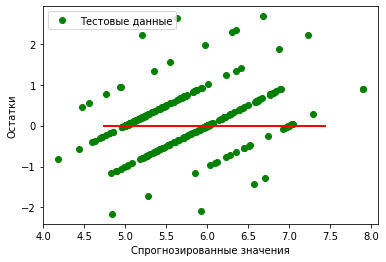

In [48]:
#  Ваш код здесь
print('RMSE_test = {:.3f}'.format(
        np.sqrt(mean_squared_error(y_test, y_pred1))))

plt.plot(y_pred1,  y_pred1 - y_test, 'og', label='Тестовые данные')
plt.xlabel('Спрогнозированные значения')
plt.ylabel('Остатки')
plt.legend(loc='upper left')
plt.plot(y_pred, np.zeros((y_pred.shape[0])), lw=2, color='red')

RMSE_test = 0.577


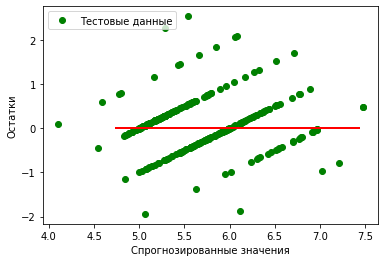

In [49]:
#  Ваш код здесь
print('RMSE_test = {:.3f}'.format(
        np.sqrt(mean_squared_error(y_test, y_pred2))))

plt.plot(y_pred2,  y_pred2 - y_test, 'og', label='Тестовые данные')
plt.xlabel('Спрогнозированные значения')
plt.ylabel('Остатки')
plt.legend(loc='upper left')
plt.plot(y_pred, np.zeros((y_pred.shape[0])), lw=2, color='red')